In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)  #n_features means each sample has 2 independent features

In [3]:
X

array([[  4.89142957,  -9.2296445 ],
       [  2.02150327, -10.093523  ],
       [  0.55054897,   1.48655122],
       ...,
       [ -1.25854943,   1.01374935],
       [  1.82896919,  -8.44252541],
       [  5.38251023,  -6.46658948]], shape=(1000, 2))

In [4]:
y

array([0, 1, 2, 1, 0, 0, 0, 2, 2, 1, 2, 0, 2, 1, 0, 2, 0, 0, 1, 1, 1, 2,
       0, 2, 0, 0, 1, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 1, 0,
       1, 0, 1, 1, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 0, 0, 2, 2, 0,
       0, 0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, 2, 0, 1, 2,
       1, 0, 0, 0, 2, 1, 0, 1, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 2, 1, 1, 2,
       1, 2, 1, 1, 2, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 2, 2, 2, 1, 0, 0, 0,
       0, 0, 0, 2, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 2, 2, 1, 1,
       2, 1, 0, 1, 2, 1, 1, 2, 0, 1, 2, 0, 2, 0, 1, 1, 1, 2, 2, 2, 0, 1,
       2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 2, 2,
       2, 2, 2, 1, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1,
       0, 1, 1, 2, 1, 2, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 1, 2, 0, 2, 0, 1, 0, 2, 1, 1, 1, 2, 0, 0, 1, 0, 2, 0, 2,
       2, 2, 0, 0, 2, 0, 0, 0, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0,
       2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1,

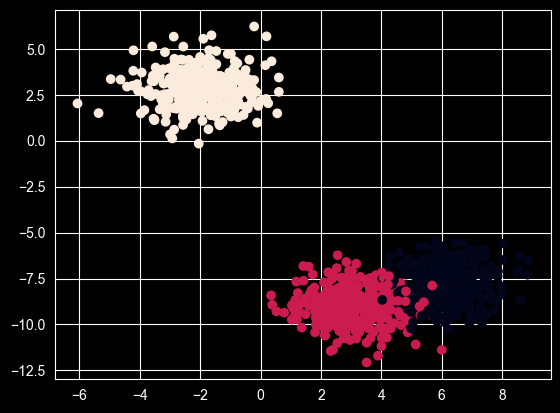

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
#Standardization --> Feature Scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [12]:
X_train_scaled = scaler.fit_transform(X_train) #we need to learn statistics.
X_test_scaled = scaler.transform(X_test)  #fit not required bcz we shouldn't need to learn statistics in test and if it learns (uses fit_transform) data leakage is happening i.e model indirectly learns from test data.

In [13]:
from sklearn.cluster import KMeans

In [14]:
#Elbow method to select K value
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)  # wcss is also called as inertia

In [15]:
wcss

[1339.9999999999995,
 166.22187170179953,
 70.32866090824872,
 57.897637721420665,
 46.476534669836724,
 39.929854133207954,
 36.76770664935295,
 33.14627981685097,
 30.02106480173055,
 26.344172255574254]

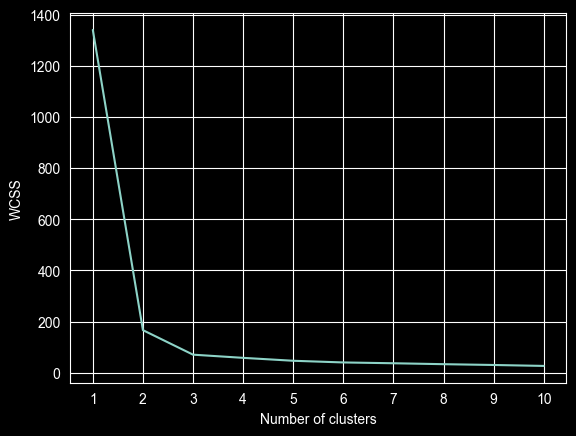

In [18]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))  #shows x-axis tick marks(1,2,3,4,5,..)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [20]:
kmeans.fit_predict(X_train_scaled)

array([2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2,
       0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 1, 2, 2, 2, 0, 0, 0, 1,
       2, 2, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 2, 0, 2, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 2, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 2, 1,
       0, 2, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 2, 2, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 0, 1, 0, 0, 2,
       0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0,

In [22]:
y_pred = kmeans.predict(X_test_scaled)

In [23]:
y_pred

array([2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 2, 0, 0, 0, 1, 1, 1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0,
       2, 0, 2, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 1,
       2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1,
       2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0,
       0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0,
       0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 2, 0, 0, 1, 0, 1, 0, 2, 0, 0, 2, 0,
       0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       2, 0, 1, 2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 2, 1, 0,
       2, 2, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 2, 0, 2,

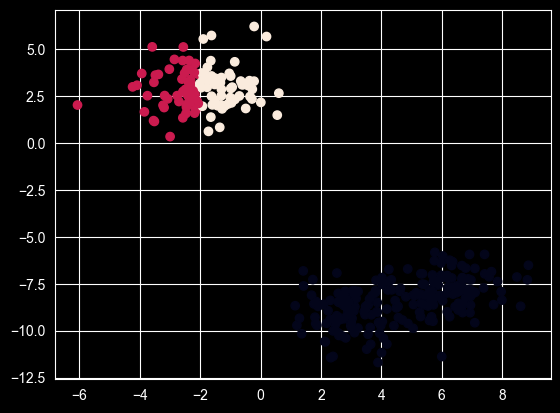

In [24]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:
#Validating the k value
#kneelocator
#Silhouette scoring

In [34]:
!"C:\Users\Sumit Dnyaneshwar\AppData\Local\Programs\Python\Python310\python.exe" -m pip install --upgrade pip


  Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 22.2.2
    Uninstalling pip-22.2.2:
      Successfully uninstalled pip-22.2.2


In [41]:
#kneelocator
!"C:\Users\Sumit Dnyaneshwar\AppData\Local\Programs\Python\Python310\python.exe" -m pip install kneed


In [43]:
from kneed import KneeLocator

In [44]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [46]:
kl.elbow

np.int64(2)

In [47]:
#Silhouette scoring
from sklearn.metrics import silhouette_score


In [48]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    scores = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(scores)

In [49]:
silhouette_coefficients

[0.7898178793243585,
 0.6537911840923133,
 0.500125593301228,
 0.39802162311559897,
 0.35058845778002284,
 0.4937450094575944,
 0.3457435047286491,
 0.3194398697967647,
 0.3207856350059254]

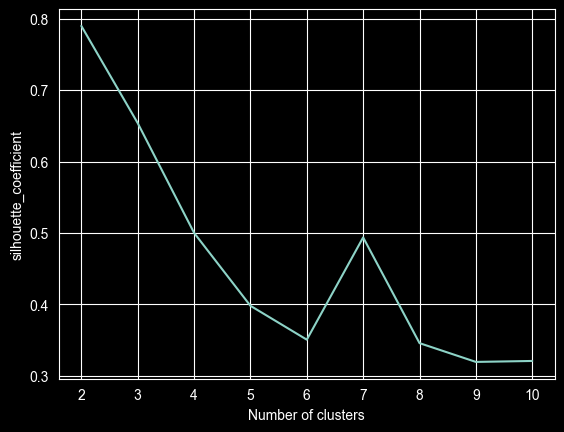

In [52]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_coefficient")
plt.show()
plt.show()